In [1]:
import warnings
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
from palettable.cartocolors.diverging import Geyser_5_r
from palettable.cartocolors.qualitative import Safe_3, Antique_5, Vivid_7
from palettable.cubehelix import cubehelix3_16
from matplotlib.patches import Patch

In [2]:
# Optional inline settings for notebooks
if 'get_ipython' in globals():
    get_ipython().run_line_magic('matplotlib', 'inline')
    get_ipython().run_line_magic('config', 'InlineBackend.figure_format = "retina"')

# Suppress warnings
warnings.filterwarnings('ignore')

# Set working directory
current_dir = os.getcwd()
fhn_dir = os.path.abspath(os.path.join(current_dir, '..'))
os.chdir(fhn_dir)
sys.path.insert(1, 'Codes/')

from myUtils import *

# Helper functions
def make_path(window, year):
    return os.path.join(fhn_dir, 'Data', 'OUTPUT', 'FPP', f'FPP_{window}_{year}.tif')

def get_custom_colormap(values, base_colors):
    n_colors = len(values)
    segmented_cmap = LinearSegmentedColormap.from_list("custom", base_colors, N=n_colors - 1)
    colors = [segmented_cmap(i / (n_colors - 2)) for i in range(n_colors - 1)]
    return ListedColormap(colors), BoundaryNorm(values, ncolors=n_colors, clip=True)

MAINPATH is set to: /home/emanuele/Research/APES/FHN


In [4]:
# Load raster data
window = 50
year = 2020
file_raster_path = make_path(window, year)
data, src = read_raster(file_raster_path)
if src.crs.to_epsg() != 4326:
    data, src = reproject_raster_to_4326(src)

PATHL = file_path = os.path.join(fhn_dir, 'Data', 'OUTPUT', 'POP', 'POP_{window}_{year}.tif')
file_raster_path = PATHL.format(window=window, year=year)
dataPOP, src = read_raster(file_raster_path)
if src.crs.to_epsg() != 4326:
    dataPOP, src = reproject_raster_to_4326(src)

dataREL2020 = 100*data / dataPOP

year = 1975
file_raster_path = make_path(window, year)
data, src = read_raster(file_raster_path)
if src.crs.to_epsg() != 4326:
    data, src = reproject_raster_to_4326(src)


PATHL = file_path = os.path.join(fhn_dir, 'Data', 'OUTPUT', 'POP', 'POP_{window}_{year}.tif')
file_raster_path = PATHL.format(window=window, year=year)
dataPOP, src = read_raster(file_raster_path)
if src.crs.to_epsg() != 4326:
    dataPOP, src = reproject_raster_to_4326(src)



dataREL1975 = 100*data / dataPOP

# Compute relative difference for Figure 1B
dataRelDiff = 100 * (dataREL2020 - dataREL1975) / dataREL1975

# Load shapefile and dataframe for bar plot
shapef = os.path.join(fhn_dir, 'Data/SHAPEFILES/world-custom_regions_r.shp')
gdf1 = gpd.read_file(shapef).to_crs("ESRI:54009")
PATHL = file_path = os.path.join(fhn_dir, 'Data', 'OUTPUT', 'FPP', 'FPP_{window}_{year}.tif')
dfData = return_df(PATHL, gdf1) 
dfData_= rel_change_df(dfData, 'median')

In [5]:

# Process data for bar plot
dfData_ = dfData_.sort_values(by='relative_change').reset_index(drop=True)


assert set(dfData_['region']).issubset(REGION_TO_CONTINENT), "Missing region-to-continent mappings"
colors1 = dfData_['region'].map(REGION_TO_CONTINENT).map(CONTINENT_COLORS)
continent_patches = [Patch(color=color, label=continent) for continent, color in CONTINENT_COLORS.items()]
cmap = LinearSegmentedColormap.from_list("Geyser_continuous", Geyser_5_r.mpl_colors, N=256)

vmin=-40
vmax=40
# Normalize and ScalarMappable
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

In [12]:
PATHL = file_path = os.path.join(fhn_dir, 'Data', 'OUTPUT', 'FPP', 'FPP_{window}_{year}.tif')
dfDataFPP = return_df(PATHL, gdf1) 
PATHL = file_path = os.path.join(fhn_dir, 'Data', 'OUTPUT', 'POP', 'POP_{window}_{year}.tif')
dfDataPOP = return_df(PATHL, gdf1) 


df1a = dfDataFPP[dfDataFPP['year']==1975].reset_index(drop=True)
df2a = dfDataPOP[dfDataPOP['year']==1975].reset_index(drop=True)

df1b = dfDataFPP[dfDataFPP['year']==2020].reset_index(drop=True)
df2b = dfDataPOP[dfDataPOP['year']==2020].reset_index(drop=True)

df11 = df1b.copy()
df11['change'] = df1b['sum'] - df1a['sum']

df22 = df2b.copy()
df22['change'] = df2b['sum'] - df2a['sum']

df_final = df11.copy()
poprel1975 = df1a['sum'] / df2a['sum']
poprel2020 = df1b['sum'] / df2b['sum']
df_final['relchange'] = 100*(poprel2020-poprel1975) / poprel1975


In [14]:
# Define colors for bar chart
CONTINENT_COLORS = {
    'Asia': Antique_5.hex_colors[0],
    'Africa': Safe_3.hex_colors[2],
    'Europe': cubehelix3_16.hex_colors[3],
    'America': Antique_5.hex_colors[3],
    'Oceania': Vivid_7.hex_colors[5]
}


df_final = df_final.sort_values(by='relchange').reset_index(drop=True)
colors = df_final['region'].map(REGION_TO_CONTINENT).map(CONTINENT_COLORS)

Text(0.01, 0.975, 'B')

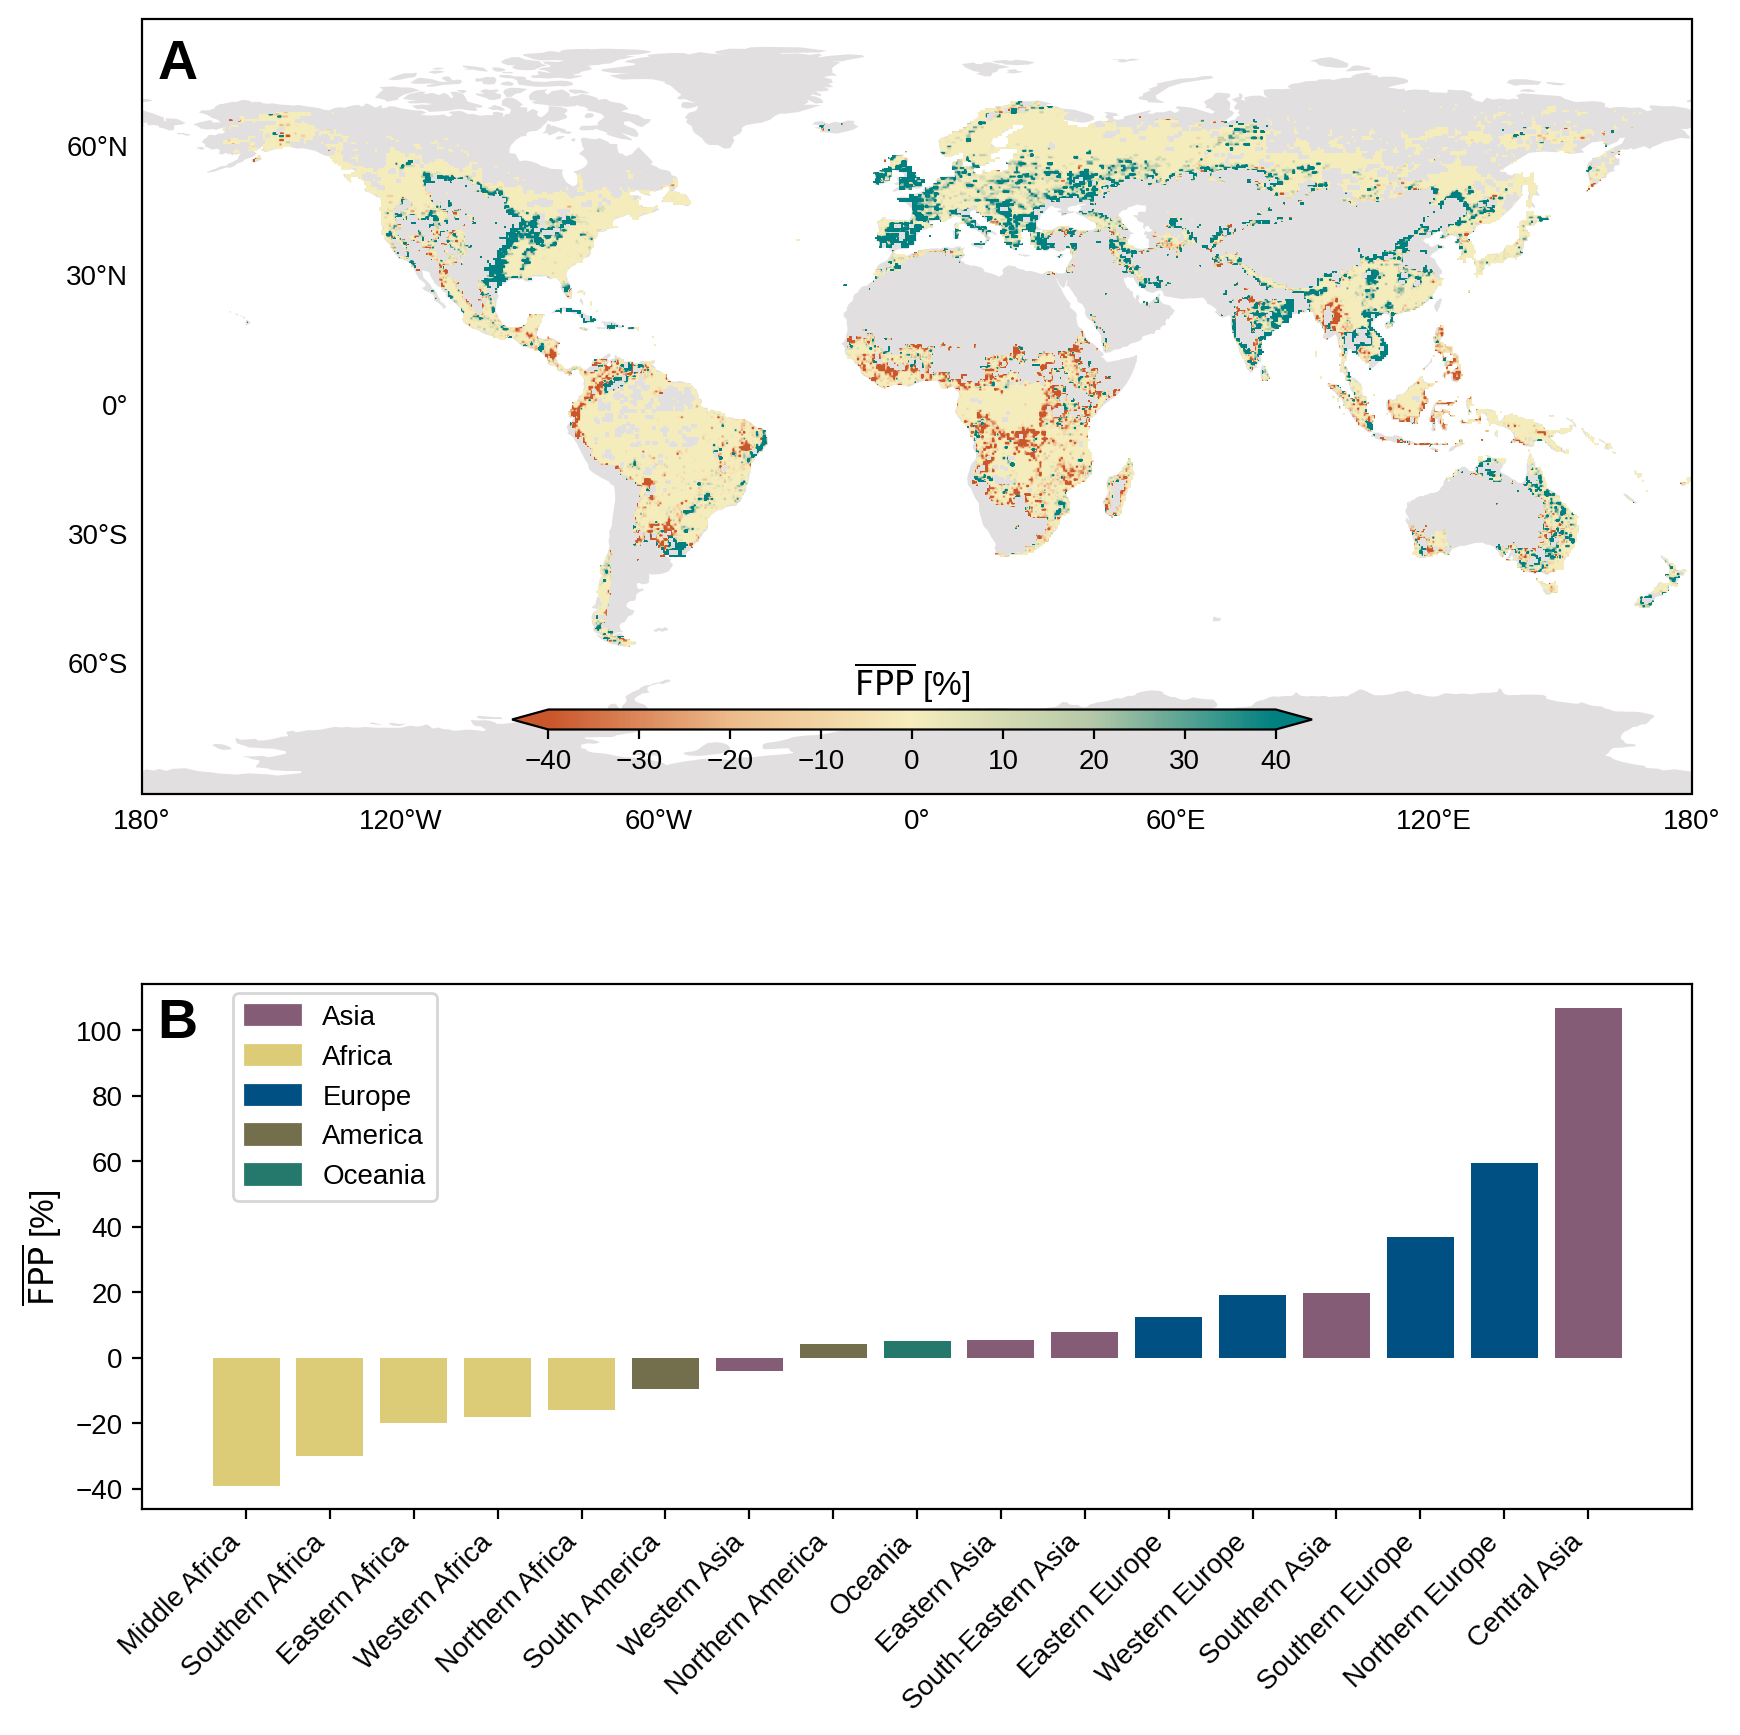

In [18]:
# Plotting
fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[2, 1.2])

# Map subplot
ax1 = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
ax1.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.OCEAN, facecolor='white')
ax1.add_feature(cfeature.LAND, facecolor='#e1dfdf')
show(dataRelDiff, cmap=cmap, vmin=vmin, vmax=vmax, ax=ax1, transform=src.transform)

gl = ax1.gridlines(draw_labels=True)
gl.xlines = gl.ylines = False
gl.top_labels = gl.right_labels = False
ax1.text(.01, .975, 'A', transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top')

# Create a new axes for the horizontal colorbar inside ax1
cbar_ax = fig.add_axes([0.31, 0.5, 0.4, 0.01])  
# Create horizontal colorbar in that axes
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label(r'$\overline{\mathrm{FPP}}$ [%]', fontsize=12, labelpad=5)
cbar.ax.tick_params(labelsize=10, direction='out')
cbar.ax.xaxis.set_label_position('top')  # Title above
cbar.ax.xaxis.tick_bottom()              # Ticks stay at bottom

# Barplot subplot
ax2 = fig.add_subplot(gs[1])

ax2.bar(df_final['region'], df_final['relchange'], color=colors)

# Axis labels and ticks
ax2.set_ylabel('$\overline{\mathrm{FPP}}$ [%]', size=12)
ax2.set_xticks(range(len(df_final['region'])))
ax2.set_xticklabels(df_final['region'], rotation=45, ha='right')


# Legend and annotation
ax2.legend(handles=continent_patches, bbox_to_anchor=(.05, 1.01), loc='upper left', fontsize=10)
ax2.text(0.01, .975, 'B', transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top')



In [19]:
fout = os.path.join(fhn_dir, 'Figures/Figure4AB_new.pdf')
fig.savefig(fout, dpi=300, bbox_inches='tight')